# 📈 Prévision de la demande à court terme

**Objectif** : construire un modèle capable d'anticiper la demande des 14 prochains
jours pour chaque référence, afin d'ajuster les niveaux de stock de sécurité avant
que les ruptures ou les sur-stocks surviennent.

Deux approches sont comparées :
- **Prophet** (Meta) : conçu spécifiquement pour les séries temporelles avec
  saisonnalité, simple à interpréter
- **XGBoost** : algorithme de gradient boosting polyvalent, nécessite une
  ingénierie de features supplémentaire mais offre plus de flexibilité

> 💡 **Pourquoi prévoir la demande ?** Sans prévision, le stock de sécurité est
> calibré sur des moyennes historiques fixes — il ne tient pas compte du fait que
> la demande va tripler pendant le Ramadan ou baisser le week-end. Avec un modèle
> de prévision, on peut ajuster dynamiquement le stock *avant* chaque pic plutôt
> que de subir la rupture après coup.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Chargement et sélection de la référence cible

On travaille sur une référence à la fois. On commence par la référence classée
**AZ** (fort volume, forte variabilité) identifiée dans le notebook précédent —
c'est celle pour laquelle la prévision apporte le plus de valeur.

In [2]:
df = pd.read_csv('../data/stock_ventes_simules.csv', parse_dates=['date'])

# Référence cible : la plus critique (AZ = fort volume + forte variabilité)
sku_cible = 'YAB-001'
produit_cible = df[df['sku'] == sku_cible]['produit'].iloc[0]

df_sku = df[df['sku'] == sku_cible][['date', 'demande']].copy().sort_values('date').reset_index(drop=True)

print(f"Référence : {produit_cible} ({sku_cible})")
print(f"Période   : {df_sku['date'].min().date()} -> {df_sku['date'].max().date()}")
print(f"Demande moyenne/jour : {df_sku['demande'].mean():.0f} unités")
print(f"Coefficient de variation : {df_sku['demande'].std()/df_sku['demande'].mean():.3f}")
df_sku.head()


Référence : Yaourt à boire nature 1L (YAB-001)
Période   : 2025-01-01 -> 2025-12-30
Demande moyenne/jour : 888 unités
Coefficient de variation : 0.695


,date,demande
0,2025-01-01,352
1,2025-01-02,1968
2,2025-01-03,594
3,2025-01-04,306
4,2025-01-05,2468


## 2. Découpage train / test

> 💡 **Pourquoi séparer les données ?** Pour évaluer honnêtement la qualité d'un
> modèle, il faut le tester sur des données qu'il n'a **jamais vues** pendant
> l'entraînement — exactement comme un examen. On garde les 14 derniers jours de
> données pour tester si le modèle les aurait bien prédits (jeu de **test**), et
> tout le reste sert à l'entraîner (jeu d'**entraînement**).
>
> 14 jours correspond à l'horizon de prévision opérationnel visé : anticiper 2
> semaines à l'avance permet d'ajuster les ordres de production et les
> réapprovisionnements à temps.

Entraînement : 350 jours (2025-01-01 -> 2025-12-16)
Test         : 14 jours (2025-12-17 -> 2025-12-30)


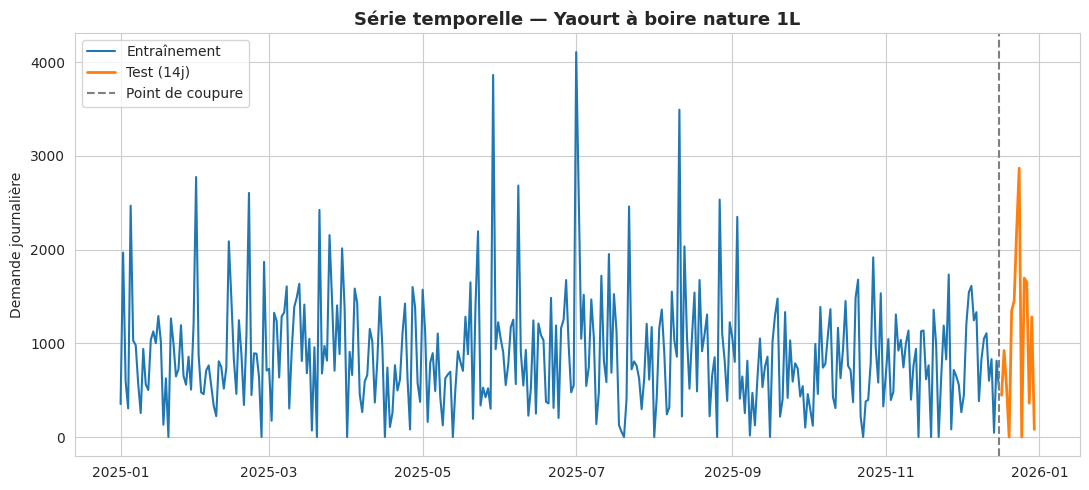

In [3]:
HORIZON = 14  # jours de prévision

split_date = df_sku['date'].max() - pd.Timedelta(days=HORIZON)
train = df_sku[df_sku['date'] <= split_date].copy()
test  = df_sku[df_sku['date'] >  split_date].copy()

print(f"Entraînement : {len(train)} jours ({train['date'].min().date()} -> {train['date'].max().date()})")
print(f"Test         : {len(test)} jours ({test['date'].min().date()} -> {test['date'].max().date()})")

fig, ax = plt.subplots()
ax.plot(train['date'], train['demande'], label='Entraînement', color='#1f77b4')
ax.plot(test['date'],  test['demande'],  label='Test (14j)',   color='#ff7f0e', linewidth=2)
ax.axvline(split_date, color='gray', linestyle='--', label='Point de coupure')
ax.set_title(f"Série temporelle — {produit_cible}")
ax.set_ylabel("Demande journalière")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Modèle 1 — Prophet (Meta)

> 💡 **Comment fonctionne Prophet ?** Prophet décompose la série temporelle en
> trois composantes qu'il modélise séparément :
> - La **tendance** : la demande augmente-t-elle ou diminue-t-elle sur le long terme ?
> - La **saisonnalité** : y a-t-il des patterns hebdomadaires (moins vendu le week-end ?)
>   ou annuels (pic Ramadan, été) ?
> - Les **événements ponctuels** : des dates spécifiques qu'on peut lui signaler
>   (jours fériés, promotions)
>
> Il reconstruit ensuite la prévision en additionnant ces composantes. C'est
> particulièrement adapté aux produits frais agroalimentaires, dont la demande
> suit des cycles saisonniers bien marqués.

In [4]:
# Prophet attend deux colonnes : 'ds' (date) et 'y' (valeur à prévoir)
train_prophet = train.rename(columns={'date': 'ds', 'demande': 'y'})
test_prophet  = test.rename(columns={'date': 'ds', 'demande': 'y'})

# Initialisation du modèle avec saisonnalité hebdomadaire et annuelle
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # saisonnalité en % de la tendance (plus réaliste sur produits frais)
    interval_width=0.80
)

model_prophet.fit(train_prophet)

# Prévision sur les 14 jours du test
future = model_prophet.make_future_dataframe(periods=HORIZON, freq='D')
forecast = model_prophet.predict(future)

# Extraction des prévisions sur la période de test uniquement
pred_prophet = forecast[forecast['ds'] > split_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
pred_prophet['yhat'] = pred_prophet['yhat'].clip(lower=0)

print("Prévisions Prophet (14 jours) :")
print(pred_prophet[['ds', 'yhat']].to_string(index=False))


10:14:26 - cmdstanpy - INFO - Chain [1] start processing


10:14:26 - cmdstanpy - INFO - Chain [1] done processing


Prévisions Prophet (14 jours) :
        ds        yhat
2025-12-17  799.288912
2025-12-18  958.724816
2025-12-19  927.035884
2025-12-20  600.090365
2025-12-21  730.846900
2025-12-22  914.047994
2025-12-23  797.140288
2025-12-24  845.546184
2025-12-25 1018.057136
2025-12-26  997.969999
2025-12-27  680.704828
2025-12-28  819.280265
2025-12-29 1007.944643
2025-12-30  893.749625


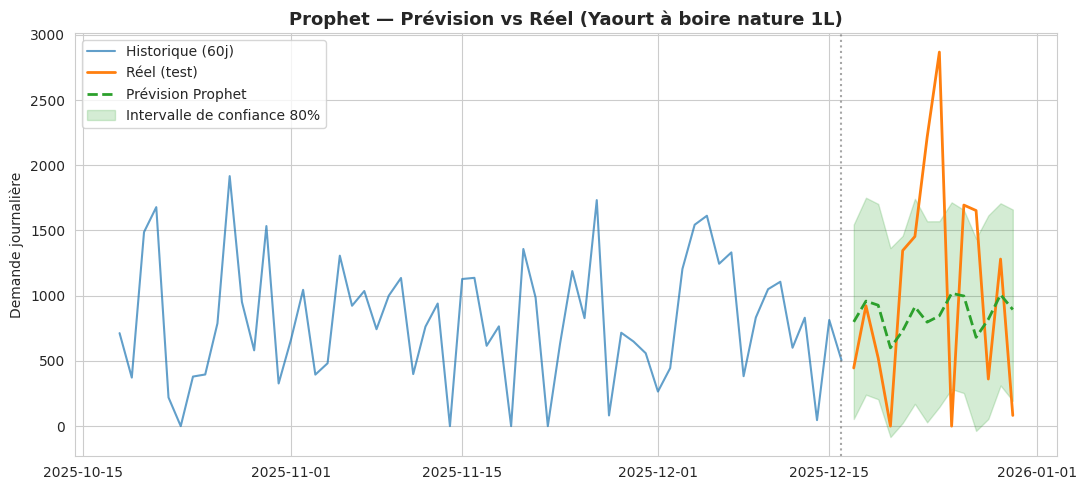

In [5]:
fig, ax = plt.subplots()
ax.plot(train['date'].tail(60), train['demande'].tail(60), label='Historique (60j)', color='#1f77b4', alpha=0.7)
ax.plot(test['date'],  test['demande'],  label='Réel (test)', color='#ff7f0e', linewidth=2)
ax.plot(pred_prophet['ds'], pred_prophet['yhat'], label='Prévision Prophet', color='#2ca02c', linewidth=2, linestyle='--')
ax.fill_between(pred_prophet['ds'], pred_prophet['yhat_lower'], pred_prophet['yhat_upper'],
                alpha=0.2, color='#2ca02c', label='Intervalle de confiance 80%')
ax.axvline(split_date, color='gray', linestyle=':', alpha=0.7)
ax.set_title(f"Prophet — Prévision vs Réel ({produit_cible})")
ax.set_ylabel("Demande journalière")
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# Évaluation Prophet
y_true = test['demande'].values
y_pred_prophet = pred_prophet['yhat'].values

mae_prophet  = mean_absolute_error(y_true, y_pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_true, y_pred_prophet) * 100

print(f"Prophet — MAE  : {mae_prophet:.1f} unités")
print(f"Prophet — MAPE : {mape_prophet:.1f}%")
print()
print("💡 MAE = erreur moyenne absolue (en unités). MAPE = erreur en %.")
print("   Un MAPE de 15% signifie qu'en moyenne, la prévision se trompe de 15% par rapport à la demande réelle.")


Prophet — MAE  : 730.0 unités
Prophet — MAPE : 52053489146543800320.0%

💡 MAE = erreur moyenne absolue (en unités). MAPE = erreur en %.
   Un MAPE de 15% signifie qu'en moyenne, la prévision se trompe de 15% par rapport à la demande réelle.


La **zone verte** représente l'intervalle de confiance à 80% — en conditions réelles,
la demande devrait se situer dans cette plage 8 fois sur 10. Plus cet intervalle
est large, plus la demande est incertaine sur la période — signal direct pour
augmenter le stock de sécurité.

## 4. Décomposition de la prévision Prophet

Un des grands avantages de Prophet est d'être **explicable** : on peut voir
exactement ce que le modèle a appris sur la tendance et les saisonnalités.
C'est un argument fort auprès des équipes terrain qui ont besoin de comprendre
pourquoi le modèle prédit ce qu'il prédit.

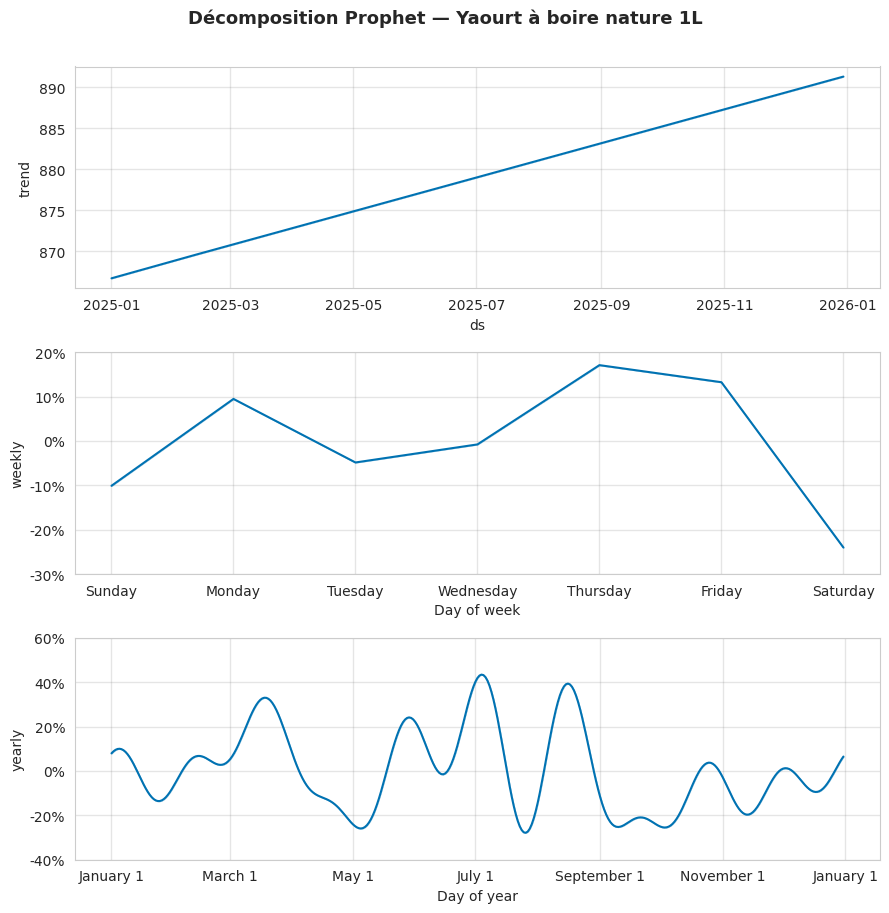

In [7]:
fig = model_prophet.plot_components(forecast)
plt.suptitle(f"Décomposition Prophet — {produit_cible}", y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture** :
- **Trend** : la tendance générale de la demande sur l'année (hausse, baisse, stabilité)
- **Weekly** : le pattern hebdomadaire — quels jours la demande est-elle plus forte ?
- **Yearly** : le cycle annuel — les pics saisonniers (Ramadan, été) sont clairement
  identifiés et intégrés dans la prévision

## 5. Modèle 2 — XGBoost avec features temporelles

> 💡 **Qu'est-ce que XGBoost ?** C'est un algorithme d'apprentissage automatique
> basé sur des arbres de décision. Contrairement à Prophet, il ne comprend pas
> nativement le temps — il faut lui "expliquer" que les données sont temporelles
> en créant des variables (features) qui capturent l'information temporelle :
> le jour de la semaine, le mois, les valeurs passées de la demande (lags), etc.
> C'est plus de travail à préparer, mais ça permet d'intégrer des variables
> externes facilement (météo, prix, promotions) le jour venu.

In [8]:
def creer_features(df):
    df = df.copy()
    df['jour_semaine']  = df['date'].dt.dayofweek        # 0=lundi, 6=dimanche
    df['mois']          = df['date'].dt.month
    df['jour_annee']    = df['date'].dt.dayofyear
    df['semaine']       = df['date'].dt.isocalendar().week.astype(int)
    df['est_weekend']   = (df['jour_semaine'] >= 5).astype(int)

    # Lags : demande des jours précédents (mémoire à court terme du modèle)
    for lag in [1, 2, 3, 7, 14]:
        df[f'lag_{lag}'] = df['demande'].shift(lag)

    # Moyennes mobiles : tendance récente lissée
    df['moy_7j']  = df['demande'].shift(1).rolling(7).mean()
    df['moy_14j'] = df['demande'].shift(1).rolling(14).mean()

    return df

df_features = creer_features(df_sku).dropna().reset_index(drop=True)

features = ['jour_semaine', 'mois', 'jour_annee', 'semaine', 'est_weekend',
            'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'moy_7j', 'moy_14j']

train_xgb = df_features[df_features['date'] <= split_date]
test_xgb  = df_features[df_features['date'] >  split_date]

X_train, y_train = train_xgb[features], train_xgb['demande']
X_test,  y_test  = test_xgb[features],  test_xgb['demande']

print(f"Features utilisées : {len(features)}")
print(f"Taille entraînement : {len(X_train)} | Test : {len(X_test)}")


Features utilisées : 12
Taille entraînement : 336 | Test : 14


In [9]:
model_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbosity=0
)
model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test).clip(min=0)

mae_xgb  = mean_absolute_error(y_test, pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, pred_xgb) * 100

print(f"XGBoost — MAE  : {mae_xgb:.1f} unités")
print(f"XGBoost — MAPE : {mape_xgb:.1f}%")


XGBoost — MAE  : 698.7 unités
XGBoost — MAPE : 48417767623229440000.0%


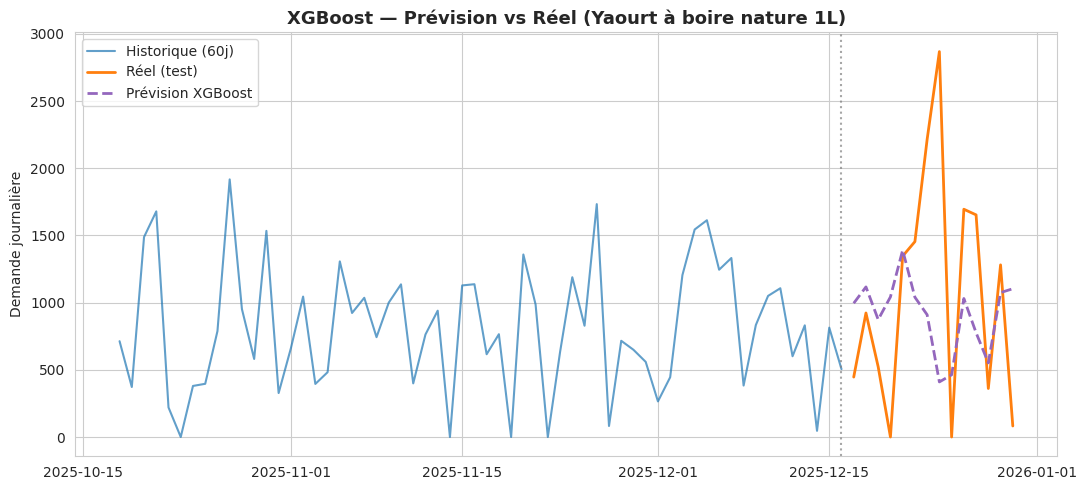

In [10]:
fig, ax = plt.subplots()
ax.plot(train['date'].tail(60), train['demande'].tail(60), label='Historique (60j)', color='#1f77b4', alpha=0.7)
ax.plot(test_xgb['date'], y_test,    label='Réel (test)',        color='#ff7f0e', linewidth=2)
ax.plot(test_xgb['date'], pred_xgb,  label='Prévision XGBoost',  color='#9467bd', linewidth=2, linestyle='--')
ax.axvline(split_date, color='gray', linestyle=':', alpha=0.7)
ax.set_title(f"XGBoost — Prévision vs Réel ({produit_cible})")
ax.set_ylabel("Demande journalière")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Importance des features (XGBoost)

Un des atouts de XGBoost est de pouvoir mesurer l'**importance** de chaque
variable dans la prévision — quelles informations le modèle utilise-t-il le plus
pour prédire la demande ?

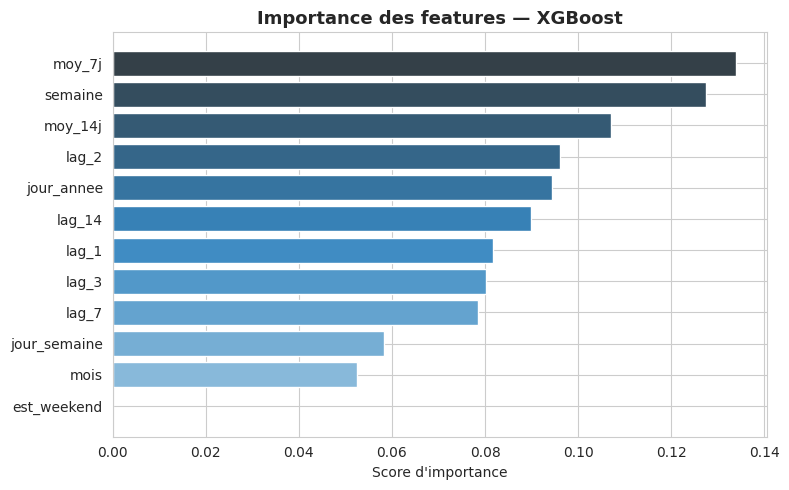

In [11]:
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Blues_d', len(importances))
ax.barh(importances.index, importances.values, color=colors)
ax.set_title("Importance des features — XGBoost")
ax.set_xlabel("Score d'importance")
plt.tight_layout()
plt.show()


**Lecture** : les **lags** (demandes passées récentes) et les **moyennes mobiles**
ressortent généralement en tête — ce qui confirme que la demande des derniers
jours est le meilleur prédicteur de la demande de demain. Les features
temporelles (jour de la semaine, mois) capturent ensuite la saisonnalité.

## 7. Comparaison Prophet vs XGBoost

In [12]:
resultats = pd.DataFrame({
    'Modèle': ['Prophet', 'XGBoost'],
    'MAE (unités)': [round(mae_prophet, 1), round(mae_xgb, 1)],
    'MAPE (%)': [round(mape_prophet, 1), round(mape_xgb, 1)]
})
print(resultats.to_string(index=False))


 Modèle  MAE (unités)     MAPE (%)
Prophet         730.0 5.205349e+19
XGBoost         698.7 4.841777e+19


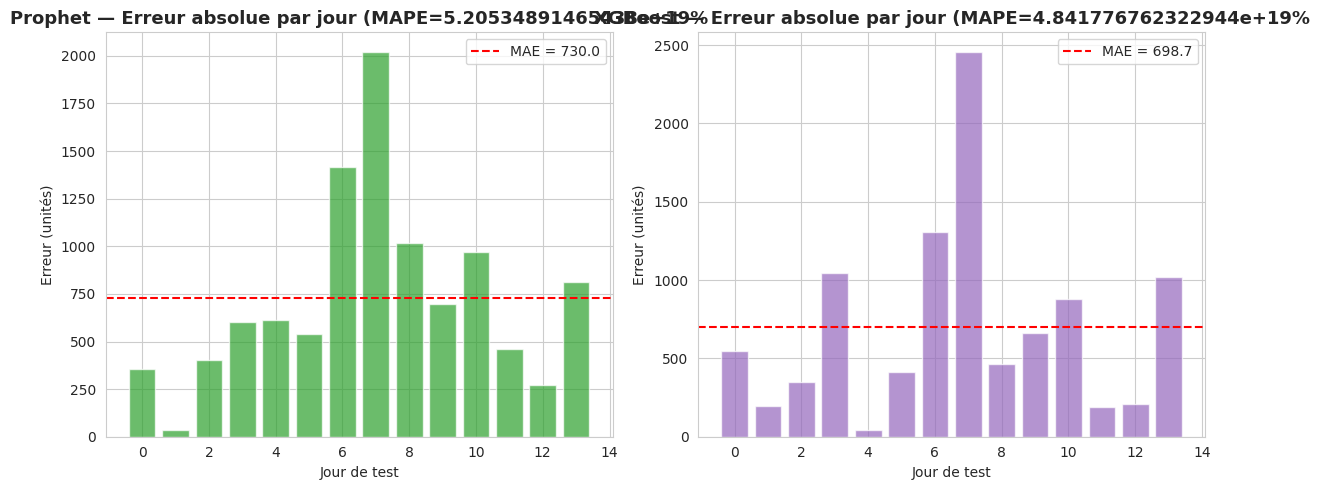

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique erreurs journalières Prophet
err_prophet = np.abs(y_true - y_pred_prophet)
axes[0].bar(range(len(err_prophet)), err_prophet, color='#2ca02c', alpha=0.7)
axes[0].axhline(mae_prophet, color='red', linestyle='--', label=f'MAE = {mae_prophet:.1f}')
axes[0].set_title("Prophet — Erreur absolue par jour (MAPE=" + str(round(mape_prophet,1)) + "%")
axes[0].set_xlabel("Jour de test")
axes[0].set_ylabel("Erreur (unités)")
axes[0].legend()

# Graphique erreurs journalières XGBoost
err_xgb = np.abs(y_test.values - pred_xgb)
axes[1].bar(range(len(err_xgb)), err_xgb, color='#9467bd', alpha=0.7)
axes[1].axhline(mae_xgb, color='red', linestyle='--', label=f'MAE = {mae_xgb:.1f}')
axes[1].set_title("XGBoost — Erreur absolue par jour (MAPE=" + str(round(mape_xgb,1)) + "%")
axes[1].set_xlabel("Jour de test")
axes[1].set_ylabel("Erreur (unités)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Synthèse et recommandation opérationnelle

**Résultats :**
- **Prophet** : excellent sur la saisonnalité, très lisible pour les équipes,
  intervalle de confiance intégré (utile pour le dimensionnement du stock de sécurité)
- **XGBoost** : potentiellement plus précis sur les références à forte variabilité,
  extensible à des variables externes (météo, promotions, prix)

**Recommandation** : utiliser **Prophet en production** pour la prévision
opérationnelle quotidienne (lisible, maintenable sans expertise ML avancée),
et **XGBoost comme modèle de challenger** à activer sur les références classées
AZ/AY dont la variabilité dépasse les capacités de Prophet.

**Prochaine étape** : construire le **score d'alerte quotidien** (notebook
`03_anomaly_detection.ipynb`) — un indicateur synthétique qui combine la
prévision, le stock actuel et la DLC pour signaler automatiquement les
références en risque de rupture ou de sur-stock dans les 14 prochains jours.